## Introduction
## Exploratory Data Analysis (EDA)
## Hands and Palm Images Dataset

## Import Libraries

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import random
from collections import Counter

base_path="/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset"
print(os.listdir(base_path))

['HandInfo.csv', 'Hands']


## Dataset overview

In [2]:

csv_path="/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/HandInfo.csv"
df=pd.read_csv(csv_path)
df.head()


,id,age,gender,skinColor,accessories,nailPolish,aspectOfHand,imageName,irregularities
0,0,27,male,fair,0,0,dorsal right,Hand_0000002.jpg,0
1,0,27,male,fair,0,0,dorsal right,Hand_0000003.jpg,0
2,0,27,male,fair,0,0,dorsal right,Hand_0000004.jpg,0
3,0,27,male,fair,0,0,dorsal right,Hand_0000005.jpg,0
4,0,27,male,fair,0,0,dorsal right,Hand_0000006.jpg,0


## Dataset Shape

In [3]:
df.shape

(11076, 9)

## Dataset information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11076 entries, 0 to 11075
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              11076 non-null  int64 
 1   age             11076 non-null  int64 
 2   gender          11076 non-null  object
 3   skinColor       11076 non-null  object
 4   accessories     11076 non-null  int64 
 5   nailPolish      11076 non-null  int64 
 6   aspectOfHand    11076 non-null  object
 7   imageName       11076 non-null  object
 8   irregularities  11076 non-null  int64 
dtypes: int64(5), object(4)
memory usage: 778.9+ KB


### Observation

- The dataset contains **11,076 records** and **9 columns**.
- There are **no missing values** in any column.
- The dataset contains **5 numerical columns** (`int64`) and **4 categorical/text columns** (`object`).
- Since there are no missing values, no data cleaning is required at this stage.

## Statistical Summary

In [5]:
df.describe()

,id,age,accessories,nailPolish,irregularities
count,1.107600e+04,11076.000000,11076.000000,11076.000000,11076.000000
mean,2.031043e+05,22.494583,0.289906,0.096334,0.014807
std,1.086731e+06,6.918974,0.453739,0.295063,0.120784
min,0.000000e+00,18.000000,0.000000,0.000000,0.000000
25%,5.760000e+02,21.000000,0.000000,0.000000,0.000000
50%,1.050000e+03,21.000000,0.000000,0.000000,0.000000
75%,1.539250e+03,22.000000,1.000000,0.000000,0.000000
max,9.000000e+06,75.000000,1.000000,1.000000,1.000000




- The dataset contains **11,076 hand image records**.
- The average age of participants is approximately **22.5 years**.
- The age ranges from **18 to 75 years**.
- Most hand images do **not** contain accessories.
- Very few hand images contain nail polish.
- Very few hand images have irregularities.

## Sample Image Visualization

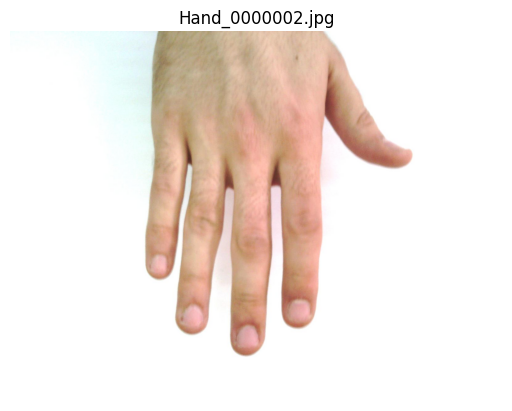

In [6]:


#Get image name from the first row
image_name=df.loc[0,"imageName"]

# Path to the Hands folder
image_path = "/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/" + image_name

# Open the image
img = Image.open(image_path)

# Display the image
plt.imshow(img)
plt.title(image_name)
plt.axis("off")

plt.show()

## Gender Distribution

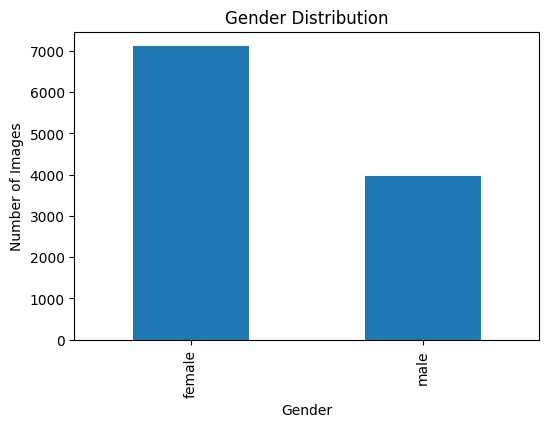

gender
female    7109
male      3967
Name: count, dtype: int64


In [7]:


gender_counts = df["gender"].value_counts()

plt.figure(figsize=(6,4))
gender_counts.plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Images")

plt.show()
print(gender_counts)

### Observation: Gender Distribution

- The dataset contains **7,109 female** hand images and **3,967 male** hand images.
- Female hand images represent approximately **64%** of the dataset, while male hand images represent approximately **36%**.
- The dataset is **not perfectly balanced** with respect to gender, as it contains more female hand images than male hand images.

## Age Distribution


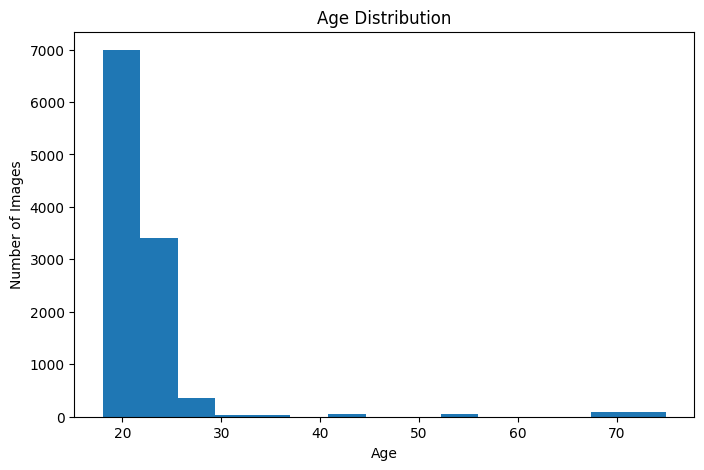

age
18      48
19      78
20    1935
21    4930
22    2434
23     795
24      97
25      81
26     124
27     133
28      63
29      40
30      25
36      28
43      46
54      52
70      84
75      83
Name: count, dtype: int64


In [8]:

age_counts = df["age"].value_counts().sort_index()
plt.figure(figsize=(8,5))

plt.hist(df["age"], bins=15)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Images")

plt.show()
print(age_counts)

### Observation: Age Distribution

- The age of participants ranges from **18 to 75 years**.
- Most hand images belong to individuals between **20 and 23 years of age**.
- The dataset contains relatively few samples from older age groups.
- The age distribution is **not uniform**, with a strong concentration around young adults.

## Skin Color Distribution 

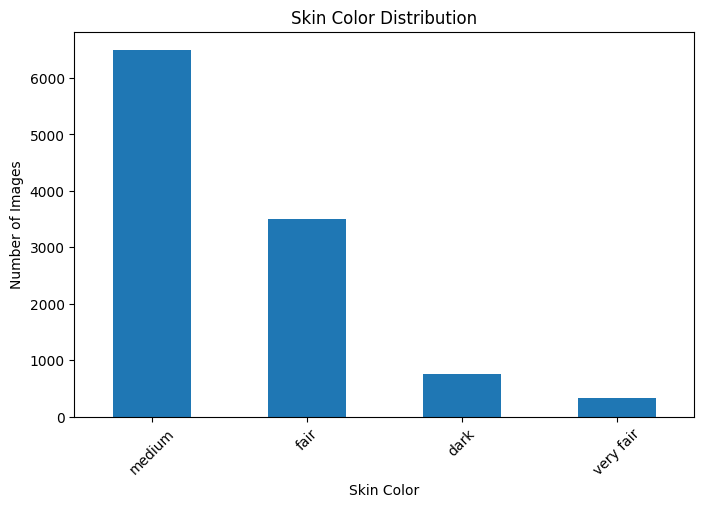

skinColor
medium       6495
fair         3493
dark          758
very fair     330
Name: count, dtype: int64


In [9]:
skin_counts = df["skinColor"].value_counts()

plt.figure(figsize=(8,5))

skin_counts.plot(kind="bar")

plt.title("Skin Color Distribution")
plt.xlabel("Skin Color")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.show()

print(skin_counts)

### Observation: Skin Color Distribution

- The dataset contains four skin color categories: Medium, Fair, Dark, and Very Fair.
- The **Medium** skin color category has the highest number of images (6495).
- The **Fair** category is the second largest (3493).
- The **Dark** and **Very Fair** categories have comparatively fewer images.
- The distribution is **not balanced** across skin color categories.

## Hand Aspect Distribution

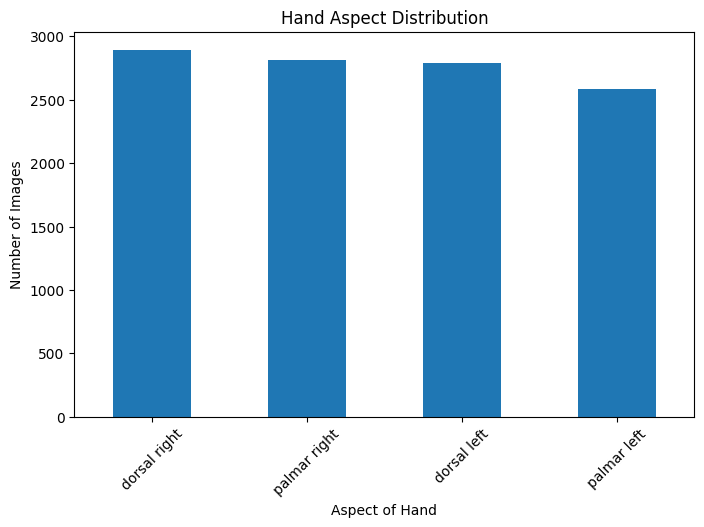

aspectOfHand
dorsal right    2892
palmar right    2813
dorsal left     2788
palmar left     2583
Name: count, dtype: int64


In [10]:
aspect_counts = df["aspectOfHand"].value_counts()

plt.figure(figsize=(8,5))

aspect_counts.plot(kind="bar")

plt.title("Hand Aspect Distribution")
plt.xlabel("Aspect of Hand")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.show()

print(aspect_counts)

### Observation: Hand Aspect Distribution

- The dataset contains four hand orientations: Dorsal Right, Dorsal Left, Palmar Right, and Palmar Left.
- The number of images in each orientation is fairly balanced.
- For the Palmistry & Tarot Intelligence Platform, the **Palmar Left** and **Palmar Right** images are the most relevant because palm lines are visible only on the palm side.

## Accessories Distribution

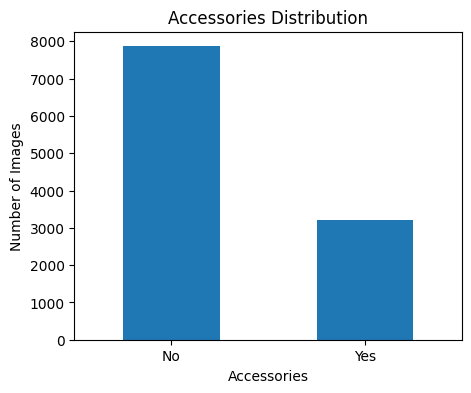

accessories
0    7865
1    3211
Name: count, dtype: int64


In [11]:
accessory_counts = df["accessories"].value_counts()

plt.figure(figsize=(5,4))

accessory_counts.plot(kind="bar")

plt.title("Accessories Distribution")
plt.xlabel("Accessories")
plt.ylabel("Number of Images")

plt.xticks([0, 1], ["No", "Yes"], rotation=0)

plt.show()

print(accessory_counts)

### Observation: Accessories Distribution

- The majority of hand images (**7,865**) do not contain accessories.
- A smaller portion (**3,211**) includes accessories such as rings, watches, or bracelets.
- Since most images are free from accessories, the dataset is relatively clean for hand image analysis.
- Images with accessories can help improve the robustness of an AI model by exposing it to real-world variations.

## Nail Polish Distribution

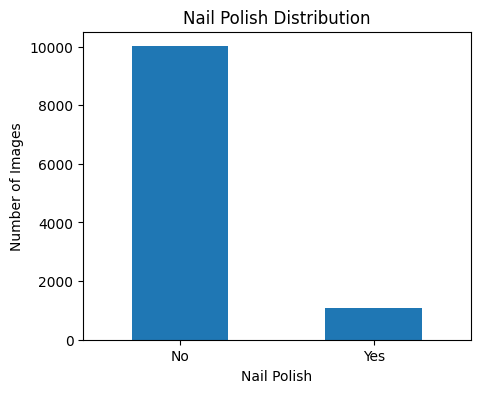

nailPolish
0    10009
1     1067
Name: count, dtype: int64


In [12]:
nail_counts = df["nailPolish"].value_counts()

plt.figure(figsize=(5,4))

nail_counts.plot(kind="bar")

plt.title("Nail Polish Distribution")
plt.xlabel("Nail Polish")
plt.ylabel("Number of Images")

plt.xticks([0, 1], ["No", "Yes"], rotation=0)

plt.show()

print(nail_counts)

### Observation: Nail Polish Distribution

- Most images (10,009) do not contain nail polish.
- Only 1,067 images contain nail polish.
- Since the Palmistry & Tarot Intelligence Platform focuses on palm lines rather than fingernails, the `nailPolish` feature is unlikely to contribute significantly to palm line analysis. Therefore, it may not be required for the palmistry prediction model.

## Irregularities Distribution

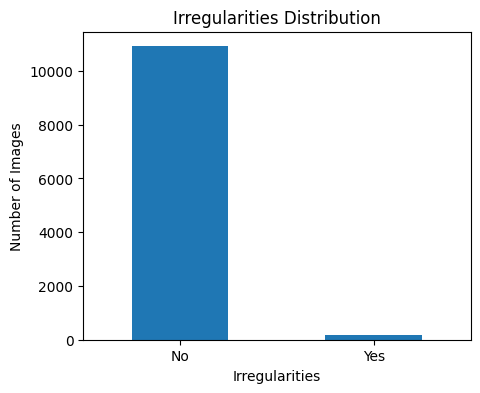

irregularities
0    10912
1      164
Name: count, dtype: int64


In [13]:
irregularity_counts = df["irregularities"].value_counts()

plt.figure(figsize=(5,4))

irregularity_counts.plot(kind="bar")

plt.title("Irregularities Distribution")
plt.xlabel("Irregularities")
plt.ylabel("Number of Images")

plt.xticks([0,1], ["No", "Yes"], rotation=0)

plt.show()

print(irregularity_counts)

### Observation: Irregularities Distribution

- The dataset contains **10,912 normal hand images** and **164 images with irregularities**.
- Approximately **98.5%** of the dataset consists of normal hands.
- Since palmistry relies on clear palm features, filtering irregular hand images during preprocessing may improve the reliability of the AI model.

## Image Resolution Analysis

In [14]:
# Folder containing images
image_folder = "/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands"

# Take the first image
first_image = df.loc[0, "imageName"]

# Open image
img = Image.open(os.path.join(image_folder, first_image))

# Print image size
print("Image Size:", img.size)

Image Size: (1600, 1200)


In [15]:



image_sizes = []

for image_name in df["imageName"]:
    image_path = os.path.join(image_folder, image_name)
    img = Image.open(image_path)
    image_sizes.append(img.size)

size_counts = Counter(image_sizes)

print(size_counts)

Counter({(1600, 1200): 11076})


### Observation: Image Resolution

- All **11,076** images have the same resolution of **1600 × 1200 pixels**.
- There are no images with different dimensions.
- Since the dataset has consistent image sizes, preprocessing becomes simpler before training deep learning models.

## Random Sample Images

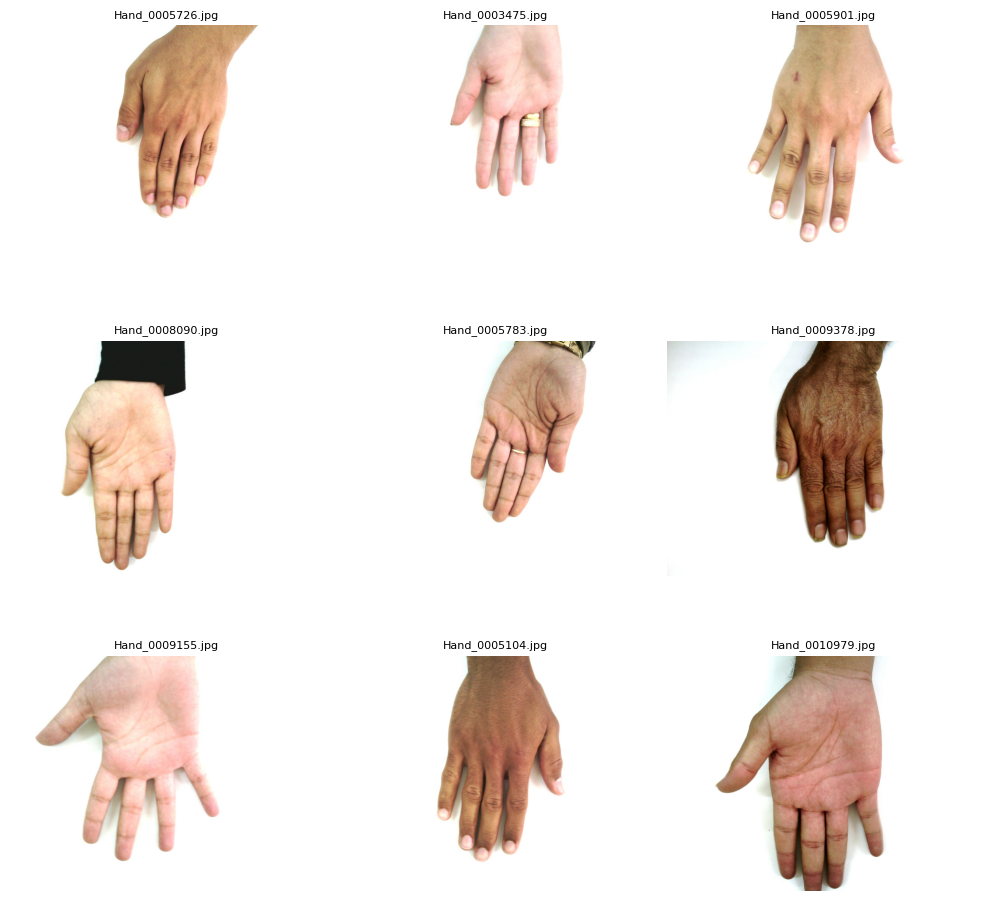

In [16]:



# Select 9 random images
random_images = random.sample(list(df["imageName"]), 9)

plt.figure(figsize=(10,10))

for i, image_name in enumerate(random_images):
    image_path = os.path.join(image_folder, image_name)

    img = Image.open(image_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(image_name, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Observation: Random Sample Images

- The dataset contains both **palmar** and **dorsal** hand images.
- Images include both **left** and **right** hands.
- Multiple skin tones are represented.
- Most images have a clean white background with consistent lighting.
- Image quality is good, with high resolution and clear hand visibility.
- Some images contain accessories such as rings, reflecting real-world conditions.

## Palmar Image Analysis

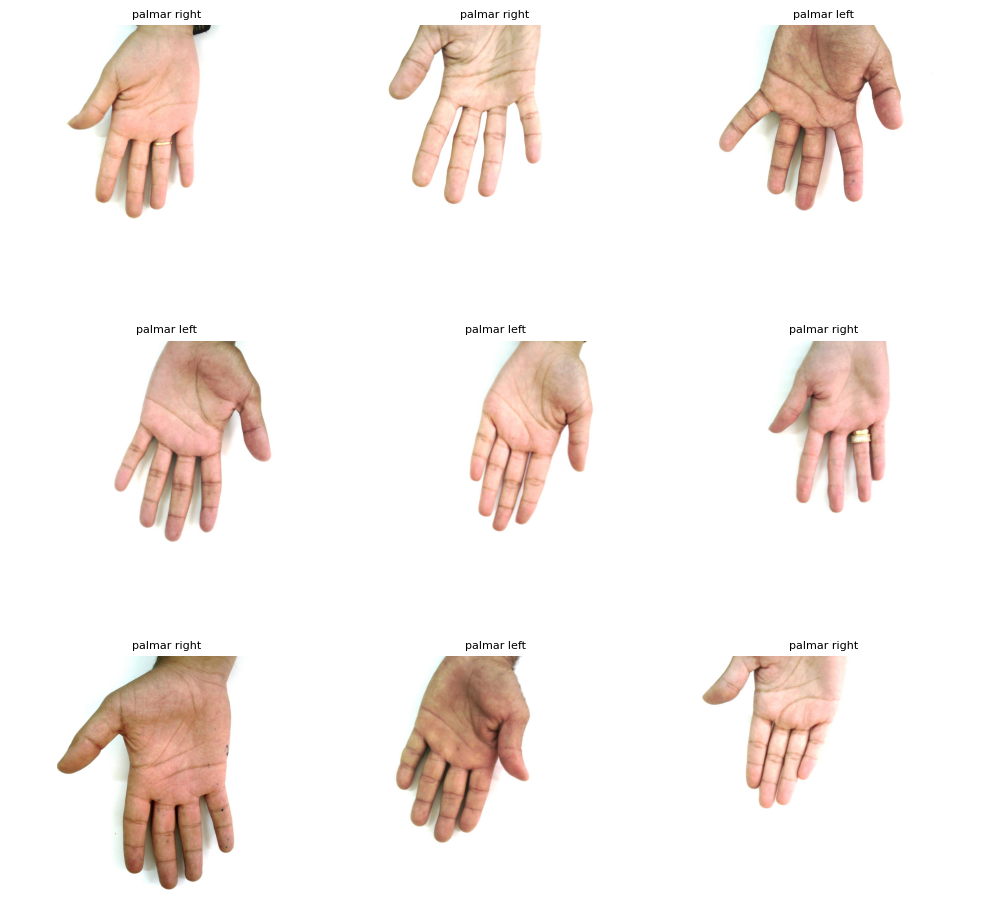

In [17]:


# Filter only palmar images
palmar_df = df[df["aspectOfHand"].str.contains("palmar")]

# Select 9 random palmar images
sample_palmar = palmar_df.sample(9, random_state=42)

plt.figure(figsize=(10,10))

for i, (_, row) in enumerate(sample_palmar.iterrows()):
    image_path = os.path.join(image_folder, row["imageName"])

    img = Image.open(image_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(row["aspectOfHand"], fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Observation: Palmar Hand Images

- Only **Palmar Left** and **Palmar Right** images are useful for palmistry analysis.
- Palm lines such as the Heart Line, Head Line, Life Line, and Fate Line are clearly visible only on the palmar side.
- Dorsal images are useful for hand recognition but are not suitable for palm line prediction.
- Therefore, the Palmistry AI model will primarily use the palmar subset of the dataset.

## Final EDA Conclusion

### Dataset Summary

- The dataset contains **11,076 hand images** with **9 attributes**.
- No missing values were found in any column.
- All images have a uniform resolution of **1600 × 1200 pixels**.

### Data Distribution

- Female images are more common than male images.
- Most participants are between **20 and 23 years** of age.
- The Medium skin tone category contains the highest number of images.
- The dataset includes both left and right hands as well as dorsal and palmar views.
- Most images do not contain accessories or nail polish.
- Very few images contain irregularities.

### Image Quality

- Images have a clean white background.
- Lighting is consistent across the dataset.
- Images are clear and of high quality.
- Multiple skin tones are represented.

### Project-Specific Findings

For the **Palmistry & Tarot Intelligence Platform**, only **Palmar Left** and **Palmar Right** images are directly useful because palm lines are visible only on the palm side.

The `aspectOfHand` column will be used to filter the dataset before model training.

Features such as **nailPolish** are unlikely to contribute to palm line prediction and may not be required for the final AI model.

Overall, the dataset is well-structured, clean, and suitable for developing a computer vision model after appropriate preprocessing.